# 05 MSOA Spatial Analysis

This notebook builds the MSOA analytical dataset and runs descriptive mapping, correlations, OLS models, Global Moran's I, Local Moran's I, and spatial-weight sensitivity tests.


## 1. Setup

### 1.1 Import packages and set paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

PROJECT_ROOT = Path(".")
BASE = PROJECT_ROOT

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

HOUSING_PATH = (
    OUTPUT_DIR /
    "pld_completed_housing_with_ptal_main_2015_2025.gpkg"
)

PTAL_PATH = BASE / "PTAL_2023_Grid_100mx100m_Data.geojson"
IMD_PATH = BASE / "ID 2019 for London.xlsx"
BOROUGH_PATH = BASE / "London_Boroughs.gpkg"

print("Housing data:", HOUSING_PATH.exists())
print("PTAL grid:", PTAL_PATH.exists())
print("IMD data:", IMD_PATH.exists())
print("Borough boundaries:", BOROUGH_PATH.exists())

Housing data: True
PTAL grid: True
IMD data: True
Borough boundaries: True


### 1.2 MSOA and LSOA 2011 boundary files

In [2]:
MSOA_PATH = BASE / "MSOA_2011_London_gen_MHW.shp"
LSOA_PATH = BASE / "LSOA_2011_London_gen_MHW.shp"

print("MSOA path:", MSOA_PATH)
print("MSOA exists:", MSOA_PATH.exists())

print("LSOA path:", LSOA_PATH)
print("LSOA exists:", LSOA_PATH.exists())

if not MSOA_PATH.exists():
    raise FileNotFoundError(f"MSOA boundary not found: {MSOA_PATH}")

if not LSOA_PATH.exists():
    raise FileNotFoundError(f"LSOA boundary not found: {LSOA_PATH}")

MSOA path: MSOA_2011_London_gen_MHW.shp
MSOA exists: True
LSOA path: LSOA_2011_London_gen_MHW.shp
LSOA exists: True


### 1.3 Helper functions

In [3]:
def find_column(columns, candidates):
    exact = {str(c): c for c in columns}
    lower = {str(c).lower(): c for c in columns}

    for candidate in candidates:
        if candidate in exact:
            return exact[candidate]
        if candidate.lower() in lower:
            return lower[candidate.lower()]

    return None


PTAL_NUMERIC_MAP = {
    "0": 0,
    "1a": 1,
    "1b": 2,
    "2": 3,
    "3": 4,
    "4": 5,
    "5": 6,
    "6a": 7,
    "6b": 8,
}


def normalise_ptal(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip().lower()
    if text.endswith(".0"):
        text = text[:-2]

    return text


def save_figure(filename):
    """Save a figure using the common dissertation style."""
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / filename,
        dpi=400,
        bbox_inches="tight",
        facecolor="#FFFFFF",
        pad_inches=0.18,
    )
    plt.show()


def remove_polygon_seams(ax):
    """
    Remove anti-aliasing seams between adjacent polygons.

    linewidth=0 removes actual polygon outlines, but very thin lines may
    still appear because Matplotlib anti-aliases each polygon separately.
    """
    for collection in ax.collections:
        if hasattr(collection, "set_antialiaseds"):
            collection.set_antialiaseds(False)

        if hasattr(collection, "set_linewidths"):
            collection.set_linewidths(0)

        if hasattr(collection, "set_edgecolors"):
            collection.set_edgecolors("none")

### 1.4 Map style

In [4]:
import matplotlib.pyplot as plt

# Clear any font/style settings left by previously executed cells
plt.rcdefaults()

plt.rcParams.update({
    "figure.facecolor": "#FFFFFF",
    "savefig.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",

    # Restore the clean sans-serif font used in the earlier version
    "font.family": "sans-serif",
    "font.sans-serif": [
        "DejaVu Sans",
        "Arial",
        "Liberation Sans",
    ],
    "font.size": 11,

    "axes.titlesize": 17,
    "axes.titleweight": "normal",
    "axes.titlecolor": "#1A1A1A",

    "legend.fontsize": 9,
    "legend.title_fontsize": 10,

    "xtick.color": "#1A1A1A",
    "ytick.color": "#1A1A1A",
    "text.color": "#1A1A1A",
})

## 2. Load and prepare data

### 2.1 Housing completions

In [5]:
housing = gpd.read_file(HOUSING_PATH).to_crs(27700)

required_housing_cols = {
    "LPA Number",
    "completed_units",
    "lsoa11cd",
    "PTAL_2023",
    "geometry",
}

missing_housing_cols = required_housing_cols.difference(housing.columns)
if missing_housing_cols:
    raise ValueError(f"Missing housing columns: {sorted(missing_housing_cols)}")

housing["completed_units"] = pd.to_numeric(
    housing["completed_units"],
    errors="coerce"
)

housing = housing[
    housing["completed_units"].notna()
    & (housing["completed_units"] > 0)
    & housing["lsoa11cd"].notna()
    & housing["PTAL_2023"].notna()
].copy()

housing["ptal_numeric_site"] = (
    housing["PTAL_2023"]
    .map(normalise_ptal)
    .map(PTAL_NUMERIC_MAP)
)

print("Housing records:", len(housing))
print("Completed units:", housing["completed_units"].sum())
print("Housing records with valid LSOA:", len(housing))

Housing records: 25829
Completed units: 225104.0
Housing records with valid LSOA: 25829


### 2.2 MSOA and LSOA 2011 boundaries

In [6]:
msoa = gpd.read_file(MSOA_PATH).to_crs(27700)
lsoa = gpd.read_file(LSOA_PATH).to_crs(27700)

msoa_code_col = find_column(
    msoa.columns,
    [
        "MSOA11CD",
        "msoa11cd",
        "MSOA11_CODE",
        "msoa11_code",
    ],
)

lsoa_code_col = find_column(
    lsoa.columns,
    [
        "LSOA11CD",
        "lsoa11cd",
        "LSOA11_CODE",
        "lsoa11_code",
    ],
)

if msoa_code_col is None:
    raise ValueError(
        "Could not identify the MSOA code column. "
        f"Available columns: {msoa.columns.tolist()}"
    )

if lsoa_code_col is None:
    raise ValueError(
        "Could not identify the LSOA code column. "
        f"Available columns: {lsoa.columns.tolist()}"
    )

msoa = (
    msoa
    .rename(columns={msoa_code_col: "msoa11cd"})
    [["msoa11cd", "geometry"]]
    .drop_duplicates(subset="msoa11cd")
    .copy()
)

lsoa = (
    lsoa
    .rename(columns={lsoa_code_col: "lsoa11cd"})
    [["lsoa11cd", "geometry"]]
    .drop_duplicates(subset="lsoa11cd")
    .copy()
)

msoa = msoa[
    msoa.geometry.notna()
    & ~msoa.geometry.is_empty
].copy()

lsoa = lsoa[
    lsoa.geometry.notna()
    & ~lsoa.geometry.is_empty
].copy()

print("MSOA polygons:", len(msoa))
print("LSOA polygons:", len(lsoa))
print("CRS:", msoa.crs)

MSOA polygons: 983
LSOA polygons: 4835
CRS: EPSG:27700


In [7]:
# Load London borough boundaries
boroughs = gpd.read_file(
    BOROUGH_PATH
).to_crs(27700)

borough_name_col = find_column(
    boroughs.columns,
    [
        "NAME",
        "Name",
        "name",
        "BOROUGH",
        "Borough",
        "borough",
        "LAD11NM",
        "LAD22NM",
        "LAD23NM",
    ],
)

if borough_name_col is None:
    raise ValueError(
        "Could not identify the borough-name column. "
        f"Available columns: {boroughs.columns.tolist()}"
    )

boroughs = (
    boroughs
    .rename(
        columns={
            borough_name_col: "borough"
        }
    )
    [["borough", "geometry"]]
    .dropna(
        subset=["borough", "geometry"]
    )
    .dissolve(
        by="borough",
        as_index=False,
    )
)

print("London local authorities:", len(boroughs))
print(boroughs["borough"].sort_values().tolist())

London local authorities: 33
['Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden', 'City of London', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster']


### 2.3 PTAL grid

In [8]:
ptal_grid = gpd.read_file(PTAL_PATH).to_crs(27700)

ptal_col = find_column(
    ptal_grid.columns,
    ["PTAL_2023", "ptal_2023", "PTAL", "ptal"],
)

if ptal_col is None:
    raise ValueError(
        "Could not identify the PTAL column. "
        f"Available columns: {ptal_grid.columns.tolist()}"
    )

ptal_grid["ptal_category"] = ptal_grid[ptal_col].map(normalise_ptal)
ptal_grid["ptal_numeric"] = ptal_grid["ptal_category"].map(PTAL_NUMERIC_MAP)

ptal_grid = ptal_grid[
    ptal_grid["ptal_numeric"].notna()
    & ptal_grid.geometry.notna()
    & ~ptal_grid.geometry.is_empty
].copy()

print("Valid PTAL grid cells:", len(ptal_grid))
print(ptal_grid["ptal_category"].value_counts().sort_index())

Valid PTAL grid cells: 159451
ptal_category
0     29944
1a    15315
1b    29675
2     39996
3     19793
4      9947
5      5431
6a     6130
6b     3220
Name: count, dtype: int64


### 2.4 Index of Multiple Deprivation

In [9]:
imd_raw = pd.read_excel(
    IMD_PATH,
    sheet_name="IMD 2019",
)

imd_code_col = find_column(
    imd_raw.columns,
    ["LSOA code (2011)", "lsoa11cd", "LSOA11CD"],
)

imd_score_col = find_column(
    imd_raw.columns,
    ["Index of Multiple Deprivation (IMD) Score", "imd_score"],
)

imd_rank_col = find_column(
    imd_raw.columns,
    [
        "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)",
        "imd_rank",
    ],
)

imd_decile_col = find_column(
    imd_raw.columns,
    [
        "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
        "imd_decile",
    ],
)

required_imd = {
    "LSOA code": imd_code_col,
    "IMD score": imd_score_col,
    "IMD rank": imd_rank_col,
    "IMD decile": imd_decile_col,
}

missing_imd = [name for name, col in required_imd.items() if col is None]
if missing_imd:
    raise ValueError(f"Missing IMD fields: {missing_imd}")

imd = (
    imd_raw[
        [
            imd_code_col,
            imd_score_col,
            imd_rank_col,
            imd_decile_col,
        ]
    ]
    .rename(
        columns={
            imd_code_col: "lsoa11cd",
            imd_score_col: "imd_score",
            imd_rank_col: "imd_rank",
            imd_decile_col: "imd_decile",
        }
    )
    .drop_duplicates(subset="lsoa11cd")
    .copy()
)

print("IMD rows:", len(imd))

IMD rows: 4835


### 2.5 Aggregate deprivation to MSOA

In [10]:
# Match each LSOA to its containing MSOA
lsoa_points = lsoa.copy()

lsoa_points = lsoa_points.drop(
    columns=["index_left", "index_right"],
    errors="ignore",
)

lsoa_points["geometry"] = (
    lsoa_points.geometry.representative_point()
)

lsoa_msoa_lookup = gpd.sjoin(
    lsoa_points,
    msoa[["msoa11cd", "geometry"]],
    how="left",
    predicate="within",
)[["lsoa11cd", "msoa11cd"]]

print(
    "LSOAs without MSOA match:",
    lsoa_msoa_lookup["msoa11cd"].isna().sum(),
)

imd_with_msoa = imd.merge(
    lsoa_msoa_lookup,
    on="lsoa11cd",
    how="left",
)

imd_msoa = (
    imd_with_msoa
    .dropna(subset=["msoa11cd"])
    .groupby("msoa11cd")
    .agg(
        mean_imd_score=("imd_score", "mean"),
        median_imd_score=("imd_score", "median"),
        mean_imd_rank=("imd_rank", "mean"),
        mean_imd_decile=("imd_decile", "mean"),
        lsoa_count=("lsoa11cd", "nunique"),
    )
    .reset_index()
)

print("MSOAs with IMD:", len(imd_msoa))

imd_msoa.head()

LSOAs without MSOA match: 0
MSOAs with IMD: 983


,msoa11cd,mean_imd_score,median_imd_score,mean_imd_rank,mean_imd_decile,lsoa_count
0,E02000001,14.805000,14.7125,20275.166667,6.666667,6
1,E02000002,34.585750,37.8810,6621.500000,2.500000,4
2,E02000003,24.880833,25.0055,11123.166667,3.833333,6
3,E02000004,23.954250,20.9670,12229.000000,4.000000,4
4,E02000005,30.928600,31.8300,8005.200000,3.000000,5


## 3. Build the MSOA analysis dataset

### 3.1 Aggregate housing completions to MSOA

In [11]:
# Remove old spatial-join index fields
housing_for_join = housing.drop(
    columns=["index_left", "index_right"],
    errors="ignore",
).copy()

msoa_for_join = msoa.drop(
    columns=["index_left", "index_right"],
    errors="ignore",
).copy()

housing_msoa_join = gpd.sjoin(
    housing_for_join,
    msoa_for_join[["msoa11cd", "geometry"]],
    how="inner",
    predicate="within",
)

housing_msoa = (
    housing_msoa_join
    .groupby("msoa11cd")
    .agg(
        housing_units=("completed_units", "sum"),
        housing_records=("LPA Number", "count"),
        mean_site_ptal=("ptal_numeric_site", "mean"),
    )
    .reset_index()
)

print("Housing records matched:", len(housing_msoa_join))
print("MSOAs with housing:", housing_msoa["msoa11cd"].nunique())
print("Matched completed units:", housing_msoa["housing_units"].sum())

housing_msoa.head()

Housing records matched: 25829
MSOAs with housing: 982
Matched completed units: 225104.0


,msoa11cd,housing_units,housing_records,mean_site_ptal
0,E02000001,540.0,37,7.972973
1,E02000002,4.0,4,2.250000
2,E02000003,77.0,13,3.538462
3,E02000004,52.0,8,2.750000
4,E02000005,11.0,9,3.333333


### 3.2 Aggregate PTAL grid cells to MSOA

In [12]:
ptal_points = ptal_grid[
    ["ptal_numeric", "geometry"]
].copy()

ptal_points = ptal_points.drop(
    columns=["index_left", "index_right"],
    errors="ignore",
)

ptal_points["geometry"] = ptal_points.geometry.centroid

ptal_msoa_join = gpd.sjoin(
    ptal_points,
    msoa[["msoa11cd", "geometry"]],
    how="inner",
    predicate="within",
)

ptal_msoa_join["medium_high_ptal"] = (
    ptal_msoa_join["ptal_numeric"] >= 4
).astype(int)

ptal_msoa_join["high_ptal"] = (
    ptal_msoa_join["ptal_numeric"] >= 6
).astype(int)

ptal_msoa = (
    ptal_msoa_join
    .groupby("msoa11cd")
    .agg(
        mean_ptal=("ptal_numeric", "mean"),
        median_ptal=("ptal_numeric", "median"),
        medium_high_ptal_share=("medium_high_ptal", "mean"),
        high_ptal_share=("high_ptal", "mean"),
        ptal_grid_cells=("ptal_numeric", "size"),
    )
    .reset_index()
)

print("PTAL cells matched:", len(ptal_msoa_join))
print("MSOAs with PTAL:", ptal_msoa["msoa11cd"].nunique())

ptal_msoa.head()

PTAL cells matched: 157322
MSOAs with PTAL: 983


,msoa11cd,mean_ptal,median_ptal,medium_high_ptal_share,high_ptal_share,ptal_grid_cells
0,E02000001,7.986348,8.0,1.000000,1.0,293
1,E02000002,1.972727,2.0,0.000000,0.0,220
2,E02000003,2.535545,3.0,0.161137,0.0,211
3,E02000004,1.645161,2.0,0.044355,0.0,248
4,E02000005,2.612069,3.0,0.206897,0.0,116


### 3.3 Merge housing, PTAL and deprivation

In [13]:
msoa_analysis = (
    msoa
    .merge(housing_msoa, on="msoa11cd", how="left")
    .merge(ptal_msoa, on="msoa11cd", how="left")
    .merge(imd_msoa, on="msoa11cd", how="left")
)

msoa_analysis["housing_units"] = (
    msoa_analysis["housing_units"].fillna(0)
)

msoa_analysis["housing_records"] = (
    msoa_analysis["housing_records"].fillna(0)
)

msoa_analysis["area_km2"] = (
    msoa_analysis.geometry.area / 1_000_000
)

msoa_analysis["housing_units_per_km2"] = (
    msoa_analysis["housing_units"]
    / msoa_analysis["area_km2"]
)

msoa_analysis["log_housing_units"] = np.log1p(
    msoa_analysis["housing_units"]
)

msoa_analysis["log_area_km2"] = np.log(
    msoa_analysis["area_km2"]
)

print("Final MSOAs:", len(msoa_analysis))

print("\nMissing values:")
print(
    msoa_analysis[
        [
            "housing_units",
            "mean_ptal",
            "medium_high_ptal_share",
            "mean_imd_score",
        ]
    ].isna().sum()
)

msoa_analysis.head()

Final MSOAs: 983

Missing values:
housing_units             0
mean_ptal                 0
medium_high_ptal_share    0
mean_imd_score            0
dtype: int64


,msoa11cd,geometry,housing_units,housing_records,mean_site_ptal,mean_ptal,median_ptal,medium_high_ptal_share,high_ptal_share,ptal_grid_cells,mean_imd_score,median_imd_score,mean_imd_rank,mean_imd_decile,lsoa_count,area_km2,housing_units_per_km2,log_housing_units,log_area_km2
0,E02000001,"MULTIPOLYGON (((531667.624 180534.992, 531647....",540.0,37.0,7.972973,7.986348,8.0,1.000000,1.0,293,14.805000,14.7125,20275.166667,6.666667,6,2.905399,185.860855,6.293419,1.066571
1,E02000002,"POLYGON ((548881.563 190845.265, 548881.125 19...",4.0,4.0,2.250000,1.972727,2.0,0.000000,0.0,220,34.585750,37.8810,6621.500000,2.500000,4,2.165634,1.847034,1.609438,0.772713
2,E02000003,"POLYGON ((549102.438 189324.625, 548954.5 1890...",77.0,13.0,3.538462,2.535545,3.0,0.161137,0.0,211,24.880833,25.0055,11123.166667,3.833333,6,2.143565,35.921467,4.356709,0.762470
3,E02000004,"POLYGON ((551549.998 187364.637, 551478 187263...",52.0,8.0,2.750000,1.645161,2.0,0.044355,0.0,248,23.954250,20.9670,12229.000000,4.000000,4,2.490215,20.881727,3.970292,0.912369
4,E02000005,"POLYGON ((549099.634 187656.076, 549161.375 18...",11.0,9.0,3.333333,2.612069,3.0,0.206897,0.0,116,30.928600,31.8300,8005.200000,3.000000,5,1.186180,9.273467,2.484907,0.170738


### 3.4 Coverage checks

In [14]:
coverage_summary = pd.DataFrame(
    {
        "measure": [
            "London MSOAs",
            "MSOAs with housing records",
            "MSOAs with PTAL",
            "MSOAs with IMD",
            "Total completed units",
        ],
        "value": [
            len(msoa_analysis),
            int((msoa_analysis["housing_records"] > 0).sum()),
            int(msoa_analysis["mean_ptal"].notna().sum()),
            int(msoa_analysis["mean_imd_score"].notna().sum()),
            msoa_analysis["housing_units"].sum(),
        ],
    }
)

coverage_summary

,measure,value
0,London MSOAs,983.0
1,MSOAs with housing records,982.0
2,MSOAs with PTAL,983.0
3,MSOAs with IMD,983.0
4,Total completed units,225104.0


## 4. MSOA maps

### 4.1 Completed housing units

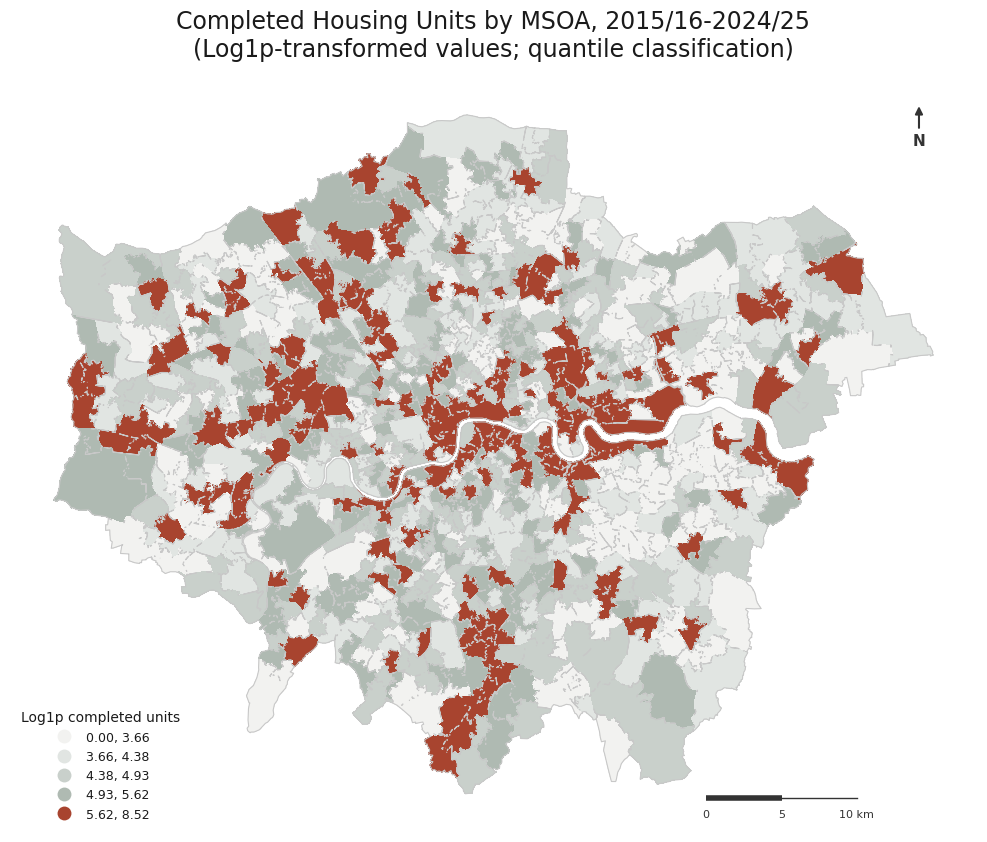

In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


# Dissolve MSOAs so that only the London-wide outline is drawn separately
london_outline = msoa_analysis.dissolve()


def add_scale_bar(
    ax,
    length_km=10,
    location=(0.75, 0.05),
    linewidth=4,
):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    bar_length_m = length_km * 1000

    start_x = x0 + (x1 - x0) * location[0]
    start_y = y0 + (y1 - y0) * location[1]

    segment_length = bar_length_m / 2

    # First half
    ax.plot(
        [start_x, start_x + segment_length],
        [start_y, start_y],
        color="#333333",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=20,
    )

    # Second half: white fill
    ax.plot(
        [start_x + segment_length, start_x + 2 * segment_length],
        [start_y, start_y],
        color="#FFFFFF",
        linewidth=linewidth,
        solid_capstyle="butt",
        zorder=20,
    )

    # Outline the white section
    ax.plot(
        [start_x + segment_length, start_x + 2 * segment_length],
        [start_y, start_y],
        color="#333333",
        linewidth=1,
        zorder=21,
    )

    label_y = start_y - (y1 - y0) * 0.015

    ax.text(
        start_x,
        label_y,
        "0",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )

    ax.text(
        start_x + segment_length,
        label_y,
        f"{length_km // 2}",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )

    ax.text(
        start_x + 2 * segment_length,
        label_y,
        f"{length_km} km",
        ha="center",
        va="top",
        fontsize=8,
        color="#333333",
    )


def add_north_arrow(
    ax,
    location=(0.94, 0.92),
    size=0.05,
):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    centre_x = x0 + (x1 - x0) * location[0]
    centre_y = y0 + (y1 - y0) * location[1]

    arrow_length = (y1 - y0) * size

    ax.annotate(
        "N",
        xy=(centre_x, centre_y + arrow_length),
        xytext=(centre_x, centre_y),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333",
        arrowprops={
            "arrowstyle": "-|>",
            "color": "#333333",
            "linewidth": 1.5,
        },
        zorder=20,
    )


housing_cmap = LinearSegmentedColormap.from_list(
    "housing_fresh",
    [
        "#F2F2F0",
        "#E1E5E2",
        "#C9D0CB",
        "#AFBBB4",
        "#A8442F",
    ],
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

msoa_analysis.plot(
    column="log_housing_units",
    scheme="Quantiles",
    k=5,
    cmap=housing_cmap,
    legend=True,

    # Remove actual boundaries
    linewidth=0,
    edgecolor="none",

    # Remove anti-aliasing seams
    antialiased=False,

    alpha=1.0,
    ax=ax,
    legend_kwds={
        "loc": "lower left",
        "title": "Log1p completed units",
        "frameon": False,
    },
    zorder=5,
)

# Force removal of any remaining polygon seams
remove_polygon_seams(ax)

# Draw only the dissolved London outline afterwards
london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)

ax.set_title(
    "Completed Housing Units by MSOA, 2015/16-2024/25\n"
    "(Log1p-transformed values; quantile classification)",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(ax)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05a_msoa_housing_units.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

### 4.2 Mean PTAL

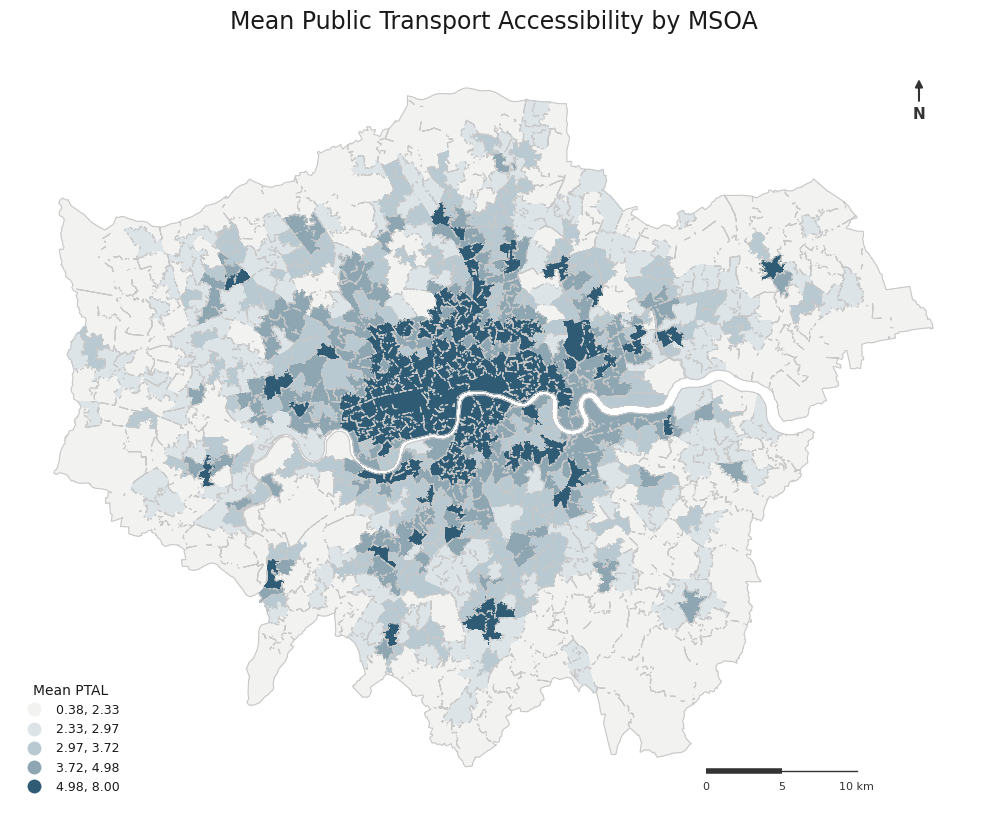

In [16]:
ptal_cmap = LinearSegmentedColormap.from_list(
    "ptal_fresh",
    [
        "#F2F2F0",
        "#DCE4E8",
        "#B8C9D1",
        "#8FA7B3",
        "#2F5C74",
    ],
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

msoa_analysis.plot(
    column="mean_ptal",
    scheme="Quantiles",
    k=5,
    cmap=ptal_cmap,
    legend=True,

    linewidth=0,
    edgecolor="none",
    antialiased=False,

    missing_kwds={
        "color": "#F0F0EC",
        "edgecolor": "none",
        "label": "No PTAL data",
    },
    ax=ax,
    legend_kwds={
        "loc": "lower left",
        "title": "Mean PTAL",
        "frameon": False,
    },
    zorder=5,
)

remove_polygon_seams(ax)

london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)

ax.set_title(
    "Mean Public Transport Accessibility by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(ax)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05b_msoa_mean_ptal.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

### 4.3 Mean deprivation score

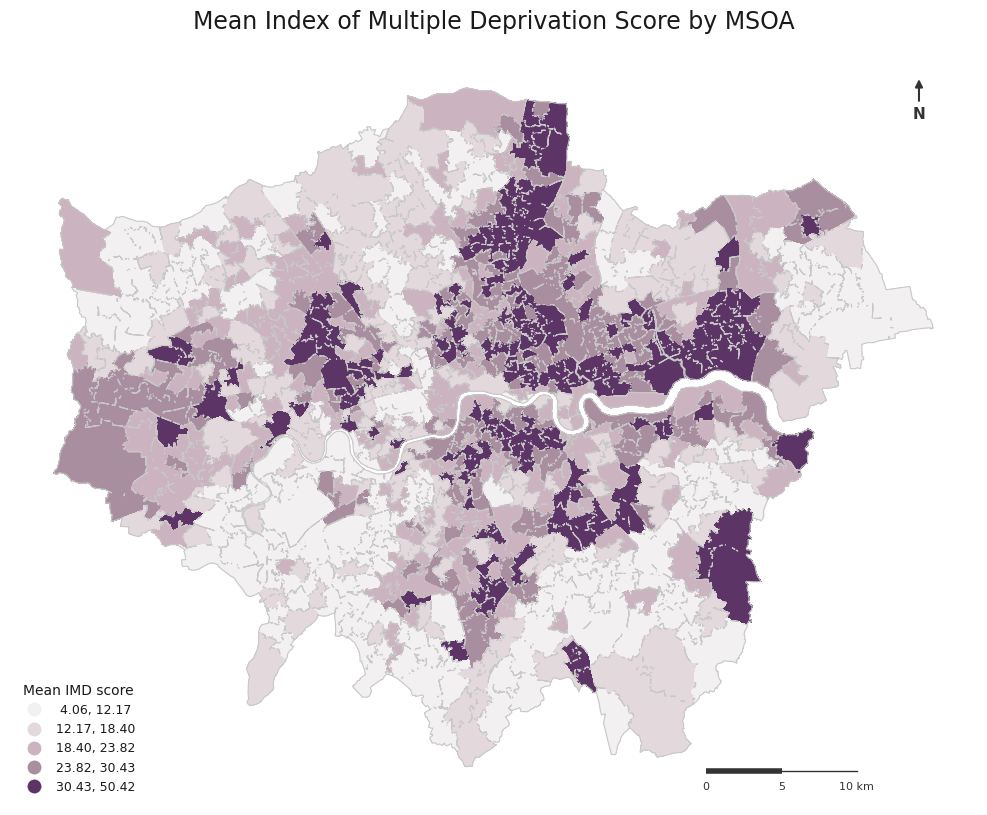

In [17]:
imd_cmap = LinearSegmentedColormap.from_list(
    "imd_fresh",
    [
        "#F2F0F0",
        "#E3D9DD",
        "#CBB4BF",
        "#A98FA0",
        "#5C3566",
    ],
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

msoa_analysis.plot(
    column="mean_imd_score",
    scheme="Quantiles",
    k=5,
    cmap=imd_cmap,
    legend=True,

    linewidth=0,
    edgecolor="none",
    antialiased=False,

    missing_kwds={
        "color": "#F0F0EC",
        "edgecolor": "none",
        "label": "No IMD data",
    },
    ax=ax,
    legend_kwds={
        "loc": "lower left",
        "title": "Mean IMD score",
        "frameon": False,
    },
    zorder=5,
)

remove_polygon_seams(ax)

london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)

ax.set_title(
    "Mean Index of Multiple Deprivation Score by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(ax)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05c_msoa_imd_score.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

### 4.4 Housing delivery density

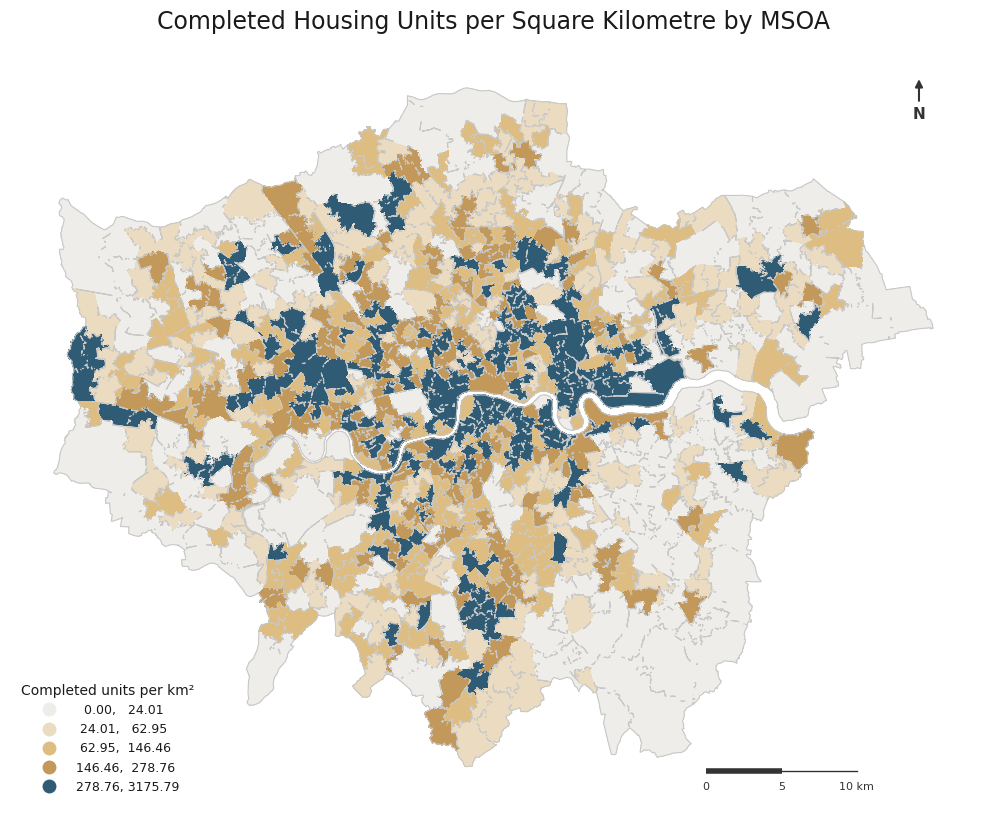

In [18]:
density_cmap = LinearSegmentedColormap.from_list(
    "density_fresh",
    [
        "#EEEDE9",
        "#EBDCC1", 
        "#DDBD82", 
        "#C49A5A",  
        "#2F5C74",  
    ],
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

msoa_analysis.plot(
    column="housing_units_per_km2",
    scheme="Quantiles",
    k=5,
    cmap=density_cmap,
    legend=True,

    linewidth=0,
    edgecolor="none",
    antialiased=False,

    ax=ax,
    legend_kwds={
        "loc": "lower left",
        "title": "Completed units per km²",
        "frameon": False,
    },
    zorder=5,
)

remove_polygon_seams(ax)

london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)

ax.set_title(
    "Completed Housing Units per Square Kilometre by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.72, 0.04),
)

add_north_arrow(ax)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05d_msoa_housing_density.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

## 5. Correlation analysis

### 5.1 Descriptive statistics

In [19]:
# Variables retained in the full descriptive statistics table
descriptive_variables = [
    "housing_units",
    "log_housing_units",
    "housing_units_per_km2",
    "mean_ptal",
    "medium_high_ptal_share",
    "mean_imd_score",
]

# Core variables used in the main correlation matrices
# Remove mathematically or conceptually repetitive variables:
# 1. housing_units and log_housing_units are monotonic transformations;
# 2. mean_ptal and medium_high_ptal_share are very strongly correlated.
correlation_variables = [
    "log_housing_units",
    "housing_units_per_km2",
    "mean_ptal",
    "mean_imd_score",
]

descriptive_statistics = (
    msoa_analysis[descriptive_variables]
    .replace([np.inf, -np.inf], np.nan)
    .describe()
    .T
)

descriptive_statistics.to_csv(
    OUTPUT_DIR / "05_msoa_descriptive_statistics.csv"
)

descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
housing_units,983.0,228.996948,441.895573,0.000000,47.000000,104.000000,233.000000,5032.000000
log_housing_units,983.0,4.653118,1.244983,0.000000,3.871201,4.653960,5.455321,8.523772
housing_units_per_km2,983.0,207.212264,327.141488,0.000000,31.206203,99.287904,231.417032,3175.787346
mean_ptal,983.0,3.633966,1.597943,0.376245,2.504628,3.299065,4.655811,8.000000
medium_high_ptal_share,983.0,0.461288,0.351480,0.000000,0.125393,0.414286,0.806046,1.000000
mean_imd_score,983.0,21.563737,9.453347,4.062400,13.746804,21.198167,28.748100,50.422500


### 5.2 Pearson and Spearman correlations

In [20]:
correlation_data = (
    msoa_analysis[correlation_variables]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print(
    "Complete observations:",
    len(correlation_data),
)

pearson_corr = correlation_data.corr(
    method="pearson"
)

spearman_corr = correlation_data.corr(
    method="spearman"
)

pearson_corr.to_csv(
    OUTPUT_DIR / "05_msoa_pearson_correlations.csv"
)

spearman_corr.to_csv(
    OUTPUT_DIR / "05_msoa_spearman_correlations.csv"
)

print("Pearson correlations")
display(pearson_corr.round(3))

print("Spearman correlations")
display(spearman_corr.round(3))

Complete observations: 983
Pearson correlations


,log_housing_units,housing_units_per_km2,mean_ptal,mean_imd_score
log_housing_units,1.000,0.684,0.280,0.112
housing_units_per_km2,0.684,1.000,0.408,0.216
mean_ptal,0.280,0.408,1.000,0.287
mean_imd_score,0.112,0.216,0.287,1.000


Spearman correlations


,log_housing_units,housing_units_per_km2,mean_ptal,mean_imd_score
log_housing_units,1.000,0.875,0.297,0.126
housing_units_per_km2,0.875,1.000,0.611,0.282
mean_ptal,0.297,0.611,1.000,0.323
mean_imd_score,0.126,0.282,0.323,1.000


### 5.3 Correlation heatmaps

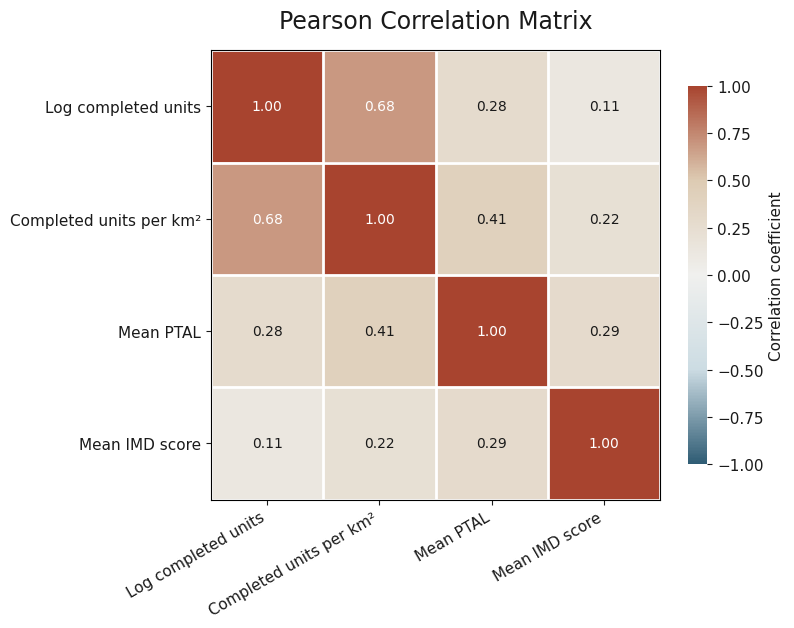

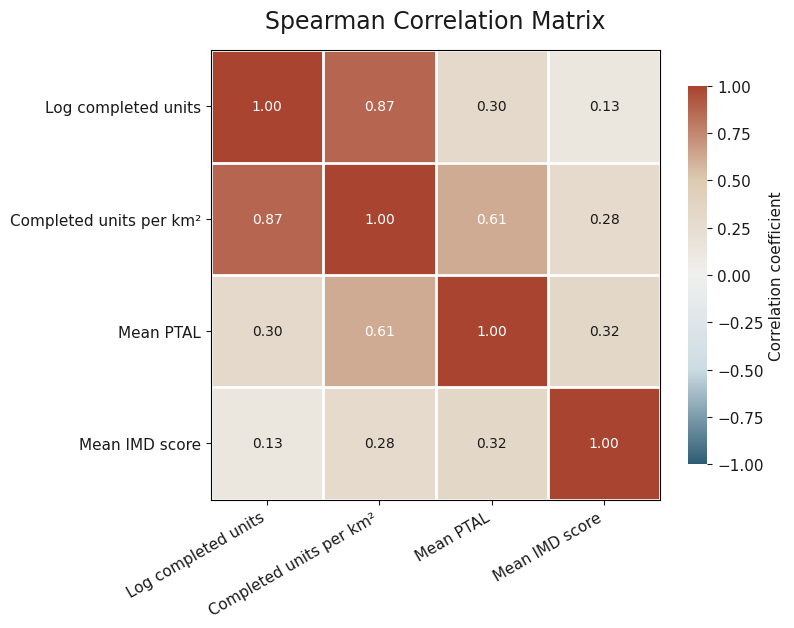

In [21]:
corr_cmap = LinearSegmentedColormap.from_list(
    "corr_fresh",
    [
        "#2F5C74",
        "#CCDCE3",
        "#F0F0EE",
        "#DDCBB3",
        "#A8442F",
    ],
)

# Replace code-style column names with publication-ready labels
variable_labels = {
    "log_housing_units": "Log completed units",
    "housing_units_per_km2": "Completed units per km²",
    "mean_ptal": "Mean PTAL",
    "mean_imd_score": "Mean IMD score",
}

correlation_outputs = [
    (
        "Pearson Correlation Matrix",
        pearson_corr,
        "fig05e_msoa_pearson_correlations.png",
    ),
    (
        "Spearman Correlation Matrix",
        spearman_corr,
        "fig05f_msoa_spearman_correlations.png",
    ),
]

for title, matrix, filename in correlation_outputs:
    plot_matrix = matrix.rename(
        index=variable_labels,
        columns=variable_labels,
    )

    fig, ax = plt.subplots(
        figsize=(8, 6.5),
        facecolor="#FFFFFF",
    )

    image = ax.imshow(
        plot_matrix.values,
        cmap=corr_cmap,
        vmin=-1,
        vmax=1,
    )

    ax.set_xticks(
        range(len(plot_matrix.columns))
    )

    ax.set_xticklabels(
        plot_matrix.columns,
        rotation=30,
        ha="right",
        color="#1A1A1A",
    )

    ax.set_yticks(
        range(len(plot_matrix.index))
    )

    ax.set_yticklabels(
        plot_matrix.index,
        color="#1A1A1A",
    )

    for row in range(len(plot_matrix.index)):
        for column in range(len(plot_matrix.columns)):
            value = plot_matrix.iloc[row, column]

            ax.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color=(
                    "white"
                    if abs(value) >= 0.55
                    else "#1A1A1A"
                ),
            )

    # Add white separation between heatmap cells
    ax.set_xticks(
        np.arange(
            -0.5,
            len(plot_matrix.columns),
            1,
        ),
        minor=True,
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(plot_matrix.index),
            1,
        ),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="#FFFFFF",
        linewidth=2,
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )

    ax.set_title(
        title,
        pad=16,
        color="#1A1A1A",
    )

    colour_bar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.82,
    )

    colour_bar.set_label(
        "Correlation coefficient",
        color="#1A1A1A",
    )

    colour_bar.outline.set_visible(False)

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / filename,
        dpi=400,
        bbox_inches="tight",
        facecolor="#FFFFFF",
        pad_inches=0.18,
    )

    plt.show()

### 5.4 Correlation coefficients and significance

In [22]:
from scipy.stats import norm, pearsonr, spearmanr


correlation_pairs = [
    (
        "Log completed units",
        "Mean PTAL",
        "log_housing_units",
        "mean_ptal",
    ),
    (
        "Log completed units",
        "Mean IMD score",
        "log_housing_units",
        "mean_imd_score",
    ),
    (
        "Completed units per km²",
        "Mean PTAL",
        "housing_units_per_km2",
        "mean_ptal",
    ),
    (
        "Completed units per km²",
        "Mean IMD score",
        "housing_units_per_km2",
        "mean_imd_score",
    ),
    (
        "Mean PTAL",
        "Mean IMD score",
        "mean_ptal",
        "mean_imd_score",
    ),
]


def format_p_value(p_value):
    """Return publication-ready p-value text."""
    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"

def fisher_ci(r, n, alpha=0.05):
    """Fisher-z confidence interval for Pearson's r."""
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    critical = norm.ppf(1 - alpha / 2)

    return np.tanh([
        z - critical * se,
        z + critical * se,
    ])


rng = np.random.default_rng(20260815)


def spearman_bootstrap_ci(x, y, n_boot=10000):
    """Percentile bootstrap confidence interval for Spearman's rho."""
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)

    estimates = np.empty(n_boot)

    for b in range(n_boot):
        index = rng.integers(0, n, n)

        estimates[b] = spearmanr(
            x[index],
            y[index],
        )[0]

    return np.quantile(
        estimates,
        [0.025, 0.975],
    )
    
correlation_results = []

for (
    variable_1,
    variable_2,
    column_1,
    column_2,
) in correlation_pairs:

    pair_data = (
        msoa_analysis[
            [
                column_1,
                column_2,
            ]
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    pearson_r, pearson_p = pearsonr(
        pair_data[column_1],
        pair_data[column_2],
    )

    spearman_rho, spearman_p = spearmanr(
        pair_data[column_1],
        pair_data[column_2],
    )
    pearson_low, pearson_high = fisher_ci(
    pearson_r,
    len(pair_data),
    )

    spearman_low, spearman_high = spearman_bootstrap_ci(
        pair_data[column_1].to_numpy(),
        pair_data[column_2].to_numpy(),
    )    
    correlation_results.append(
     {
         "variable_1": variable_1,
         "variable_2": variable_2,
         "observations": len(pair_data),
         "pearson_r": pearson_r,
         "pearson_ci_low": pearson_low,
         "pearson_ci_high": pearson_high,
         "pearson_p": pearson_p,
         "spearman_rho": spearman_rho,
         "spearman_ci_low": spearman_low,
         "spearman_ci_high": spearman_high,
         "spearman_p": spearman_p,
     }
)

# Preserve raw numeric results
correlation_results = pd.DataFrame(
    correlation_results
)

correlation_results.to_csv(
    OUTPUT_DIR / "05_msoa_correlation_tests_raw.csv",
    index=False,
)


# Create a publication-ready version
correlation_results_display = (
    correlation_results.copy()
)

correlation_results_display["pearson_r_95_ci"] = (
    correlation_results.apply(
        lambda row: (
            f"{row['pearson_r']:.3f} "
            f"[{row['pearson_ci_low']:.3f}, "
            f"{row['pearson_ci_high']:.3f}]"
        ),
        axis=1,
    )
)

correlation_results_display["spearman_rho_95_ci"] = (
    correlation_results.apply(
        lambda row: (
            f"{row['spearman_rho']:.3f} "
            f"[{row['spearman_ci_low']:.3f}, "
            f"{row['spearman_ci_high']:.3f}]"
        ),
        axis=1,
    )
)
correlation_results_display["pearson_r"] = (
    correlation_results_display["pearson_r"]
    .map(lambda value: f"{value:.3f}")
)

correlation_results_display["spearman_rho"] = (
    correlation_results_display["spearman_rho"]
    .map(lambda value: f"{value:.3f}")
)

correlation_results_display["pearson_p"] = (
    correlation_results_display["pearson_p"]
    .map(format_p_value)
)

correlation_results_display["spearman_p"] = (
    correlation_results_display["spearman_p"]
    .map(format_p_value)
)

display_columns = [
    "variable_1",
    "variable_2",
    "observations",
    "pearson_r_95_ci",
    "pearson_p",
    "spearman_rho_95_ci",
    "spearman_p",
]

correlation_results_formatted = (
    correlation_results_display[
        display_columns
    ].copy()
)

correlation_results_formatted.to_csv(
    OUTPUT_DIR / "05_msoa_correlation_tests_formatted.csv",
    index=False,
)

display(correlation_results_formatted)

,variable_1,variable_2,observations,pearson_r_95_ci,pearson_p,spearman_rho_95_ci,spearman_p
0,Log completed units,Mean PTAL,983,"0.280 [0.222, 0.337]",<0.001,"0.297 [0.237, 0.354]",<0.001
1,Log completed units,Mean IMD score,983,"0.112 [0.049, 0.173]",<0.001,"0.126 [0.062, 0.188]",<0.001
2,Completed units per km²,Mean PTAL,983,"0.408 [0.355, 0.459]",<0.001,"0.611 [0.568, 0.651]",<0.001
3,Completed units per km²,Mean IMD score,983,"0.216 [0.155, 0.274]",<0.001,"0.282 [0.220, 0.341]",<0.001
4,Mean PTAL,Mean IMD score,983,"0.287 [0.229, 0.343]",<0.001,"0.323 [0.265, 0.380]",<0.001


## 6. Spatial autocorrelation

### 6.1 Prepare the spatial dataset

In [23]:
spatial_gdf = (
    msoa_analysis
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "log_housing_units",
            "mean_ptal",
            "mean_imd_score",
            "geometry",
        ]
    )
    .reset_index(drop=True)
    .copy()
)

spatial_gdf = spatial_gdf[
    spatial_gdf.geometry.notna()
    & ~spatial_gdf.geometry.is_empty
].copy()

spatial_gdf = spatial_gdf.reset_index(drop=True)

print("Spatial observations:", len(spatial_gdf))

Spatial observations: 983


### 6.2 Create eight-nearest-neighbour weights

In [24]:
# Eight nearest MSOAs
w = KNN.from_dataframe(
    spatial_gdf,
    k=8,
    use_index=True,
)

# Make neighbour relationships symmetric
w = w.symmetrize()

# Row-standardise the weights
w.transform = "r"

print("Number of observations:", w.n)
print("Minimum neighbours:", min(w.cardinalities.values()))
print("Maximum neighbours:", max(w.cardinalities.values()))
print("Mean neighbours:", np.mean(list(w.cardinalities.values())))
print("Disconnected observations:", len(w.islands))
print("Island indices:", w.islands)

Number of observations: 983
Minimum neighbours: 8
Maximum neighbours: 14
Mean neighbours: 9.078331637843336
Disconnected observations: 0
Island indices: []


### 6.3 Global Moran’s I

In [25]:
moran_variables = {
    "Log housing units": "log_housing_units",
    "Mean PTAL": "mean_ptal",
    "Mean IMD score": "mean_imd_score",
}

moran_results = []

for label, column in moran_variables.items():
    moran = Moran(
        spatial_gdf[column].astype(float).values,
        w,
        permutations=999,
    )

    moran_results.append(
        {
            "variable": label,
            "morans_i": moran.I,
            "expected_i": moran.EI,
            "pseudo_p_value": moran.p_sim,
            "z_score": moran.z_sim,
        }
    )

moran_results = pd.DataFrame(moran_results)

moran_results.to_csv(
    OUTPUT_DIR / "05_msoa_global_morans_i.csv",
    index=False,
)

moran_results.round(4)

,variable,morans_i,expected_i,pseudo_p_value,z_score
0,Log housing units,0.1784,-0.001,0.001,11.5051
1,Mean PTAL,0.6851,-0.001,0.001,47.0325
2,Mean IMD score,0.5417,-0.001,0.001,35.6856


### 6.4 Local Moran’s I

In [26]:
lisa = Moran_Local(
    spatial_gdf["log_housing_units"].astype(float).values,
    w,
    permutations=999,
)

spatial_gdf["lisa_p"] = lisa.p_sim
spatial_gdf["lisa_q"] = lisa.q
spatial_gdf["lisa_i"] = lisa.Is

spatial_gdf["lisa_strength"] = np.abs(
    spatial_gdf["lisa_i"]
)
spatial_gdf["lisa_cluster"] = "Not significant"

significant = spatial_gdf["lisa_p"] < 0.05

spatial_gdf.loc[
    significant & (spatial_gdf["lisa_q"] == 1),
    "lisa_cluster",
] = "High–High"

spatial_gdf.loc[
    significant & (spatial_gdf["lisa_q"] == 2),
    "lisa_cluster",
] = "Low–High"

spatial_gdf.loc[
    significant & (spatial_gdf["lisa_q"] == 3),
    "lisa_cluster",
] = "Low–Low"

spatial_gdf.loc[
    significant & (spatial_gdf["lisa_q"] == 4),
    "lisa_cluster",
] = "High–Low"

cluster_order = [
    "High–High",
    "Low–Low",
    "High–Low",
    "Low–High",
    "Not significant",
]

spatial_gdf["lisa_cluster"] = pd.Categorical(
    spatial_gdf["lisa_cluster"],
    categories=cluster_order,
    ordered=True,
)

spatial_gdf["lisa_cluster"].value_counts(dropna=False)

lisa_cluster
Not significant    745
Low–Low             90
High–High           86
Low–High            36
High–Low            26
Name: count, dtype: int64

In [27]:
# Assign each MSOA to a London borough using a representative point
msoa_points = spatial_gdf[
    [
        "msoa11cd",
        "geometry",
    ]
].copy()

msoa_points["geometry"] = (
    msoa_points
    .geometry
    .representative_point()
)

msoa_to_borough = gpd.sjoin(
    msoa_points,
    boroughs,
    how="left",
    predicate="within",
)

msoa_to_borough = (
    msoa_to_borough
    [
        [
            "msoa11cd",
            "borough",
        ]
    ]
    .drop_duplicates(
        subset="msoa11cd"
    )
)

spatial_gdf = (
    spatial_gdf
    .drop(
        columns=["borough"],
        errors="ignore",
    )
    .merge(
        msoa_to_borough,
        on="msoa11cd",
        how="left",
        validate="one_to_one",
    )
)

print(
    "MSOAs without borough:",
    spatial_gdf["borough"].isna().sum(),
)

MSOAs without borough: 0


In [28]:
cluster_order = [
    "High–High",
    "Low–Low",
    "High–Low",
    "Low–High",
    "Not significant",
]

lisa_borough_summary = (
    pd.crosstab(
        spatial_gdf["borough"],
        spatial_gdf["lisa_cluster"],
    )
    .reindex(
        columns=cluster_order,
        fill_value=0,
    )
    .reset_index()
)

lisa_borough_summary[
    "Significant total"
] = (
    lisa_borough_summary[
        [
            "High–High",
            "Low–Low",
            "High–Low",
            "Low–High",
        ]
    ]
    .sum(axis=1)
)

lisa_borough_summary[
    "MSOA total"
] = (
    lisa_borough_summary[
        cluster_order
    ]
    .sum(axis=1)
)

lisa_borough_summary[
    "High–High share"
] = (
    lisa_borough_summary["High–High"]
    / lisa_borough_summary["MSOA total"]
)

lisa_borough_summary[
    "Low–Low share"
] = (
    lisa_borough_summary["Low–Low"]
    / lisa_borough_summary["MSOA total"]
)

lisa_borough_summary.to_csv(
    OUTPUT_DIR
    / "05_lisa_cluster_counts_by_borough.csv",
    index=False,
)

print("Boroughs with most High–High MSOAs")
display(
    lisa_borough_summary
    .sort_values(
        [
            "High–High",
            "High–High share",
        ],
        ascending=False,
    )
    .head(10)
)

print("Boroughs with most Low–Low MSOAs")
display(
    lisa_borough_summary
    .sort_values(
        [
            "Low–Low",
            "Low–Low share",
        ],
        ascending=False,
    )
    .head(10)
)

Boroughs with most High–High MSOAs


lisa_cluster,borough,High–High,Low–Low,High–Low,Low–High,Not significant,Significant total,MSOA total,High–High share,Low–Low share
7,Croydon,17,6,0,1,20,24,44,0.386364,0.136364
27,Southwark,10,0,0,1,22,11,33,0.303030,0.000000
1,Barnet,10,0,0,4,27,14,41,0.243902,0.000000
29,Tower Hamlets,7,0,0,3,22,10,32,0.218750,0.000000
3,Brent,7,1,0,1,25,9,34,0.205882,0.029412
24,Newham,7,2,0,3,25,12,37,0.189189,0.054054
8,Ealing,7,0,0,2,30,9,39,0.179487,0.000000
32,Westminster,5,0,0,3,16,8,24,0.208333,0.000000
16,Hillingdon,3,0,1,2,26,6,32,0.093750,0.000000
21,Lambeth,3,0,0,4,28,7,35,0.085714,0.000000


Boroughs with most Low–Low MSOAs


lisa_cluster,borough,High–High,Low–Low,High–Low,Low–High,Not significant,Significant total,MSOA total,High–High share,Low–Low share
10,Greenwich,0,21,2,0,10,23,33,0.000000,0.636364
0,Barking and Dagenham,0,13,3,0,6,16,22,0.000000,0.590909
18,Islington,1,8,0,0,14,9,23,0.043478,0.347826
2,Bexley,0,7,6,0,15,13,28,0.000000,0.250000
4,Bromley,0,7,4,0,28,11,39,0.000000,0.179487
25,Redbridge,0,6,3,0,22,9,31,0.000000,0.193548
22,Lewisham,1,6,0,0,29,7,36,0.027778,0.166667
7,Croydon,17,6,0,1,20,24,44,0.386364,0.136364
17,Hounslow,0,5,3,0,20,8,28,0.000000,0.178571
9,Enfield,0,4,0,0,32,4,36,0.000000,0.111111


In [29]:
high_low_outliers = (
    spatial_gdf.loc[
        spatial_gdf["lisa_cluster"]
        == "High–Low"
    ]
    .nlargest(
        4,
        "lisa_strength",
    )
    .copy()
)

low_high_outliers = (
    spatial_gdf.loc[
        spatial_gdf["lisa_cluster"]
        == "Low–High"
    ]
    .nlargest(
        4,
        "lisa_strength",
    )
    .copy()
)

selected_outliers = pd.concat(
    [
        high_low_outliers,
        low_high_outliers,
    ],
    ignore_index=False,
).copy()

selected_outliers[
    "map_label"
] = range(
    1,
    len(selected_outliers) + 1,
)

selected_outlier_table = (
    selected_outliers[
        [
            "map_label",
            "msoa11cd",
            "borough",
            "lisa_cluster",
            "housing_units",
            "log_housing_units",
            "lisa_i",
            "lisa_p",
        ]
    ]
    .sort_values("map_label")
)

selected_outlier_table.to_csv(
    OUTPUT_DIR
    / "05_selected_lisa_outliers.csv",
    index=False,
)

display(selected_outlier_table)

,map_label,msoa11cd,borough,lisa_cluster,housing_units,log_housing_units,lisa_i,lisa_p
76,1,E02000079,Bexley,High–Low,783.0,6.664409,-1.427403,0.005
64,2,E02000066,Bexley,High–Low,548.0,6.308098,-1.374497,0.002
149,3,E02000154,Bromley,High–Low,466.0,6.146329,-1.055829,0.003
21,4,E02000023,Barking and Dagenham,High–Low,291.0,5.676754,-0.967109,0.001
861,5,E02000894,Tower Hamlets,Low–High,4.0,1.609438,-2.571575,0.001
723,6,E02000748,Newham,Low–High,4.0,1.609438,-2.069905,0.005
717,7,E02000742,Newham,Low–High,9.0,2.302585,-1.160676,0.014
601,8,E02000623,Lambeth,Low–High,14.0,2.708050,-1.125718,0.013


In [30]:
# ============================================================
# Identify the largest housing scheme in each selected
# LISA outlier MSOA
# ============================================================

# Work on a copy so that the original housing GeoDataFrame
# is not altered.
housing_for_context = housing.copy()

# GeoPandas creates these fields during spatial joins.
# They must be removed before another gpd.sjoin().
housing_for_context = housing_for_context.drop(
    columns=[
        "index_right",
        "index_left",
    ],
    errors="ignore",
)

# Ensure that housing and MSOA polygons use the same CRS.
housing_for_context = housing_for_context.to_crs(
    msoa.crs
)

# ------------------------------------------------------------
# 1. Check whether housing already has an MSOA code
# ------------------------------------------------------------

possible_existing_msoa_columns = [
    "msoa11cd",
    "MSOA11CD",
    "msoa11cd_left",
    "msoa11cd_right",
]

existing_msoa_col = next(
    (
        column
        for column in possible_existing_msoa_columns
        if (
            column in housing_for_context.columns
            and housing_for_context[column].notna().any()
        )
    ),
    None,
)

if existing_msoa_col is not None:

    print(
        "Using existing MSOA field:",
        existing_msoa_col,
    )

    # Standardise the field name.
    if existing_msoa_col != "msoa11cd":

        housing_for_context = (
            housing_for_context
            .drop(
                columns=["msoa11cd"],
                errors="ignore",
            )
            .rename(
                columns={
                    existing_msoa_col:
                    "msoa11cd"
                }
            )
        )

    housing_msoa = housing_for_context.copy()

else:

    print(
        "No existing MSOA field found. "
        "Running a new point-in-polygon join."
    )

    # Remove any empty or obsolete MSOA fields before joining.
    housing_for_context = (
        housing_for_context
        .drop(
            columns=[
                "msoa11cd",
                "MSOA11CD",
                "msoa11cd_left",
                "msoa11cd_right",
            ],
            errors="ignore",
        )
    )

    msoa_for_join = (
        msoa[
            [
                "msoa11cd",
                "geometry",
            ]
        ]
        .drop(
            columns=[
                "index_right",
                "index_left",
            ],
            errors="ignore",
        )
        .copy()
    )

    housing_msoa = gpd.sjoin(
        housing_for_context,
        msoa_for_join,
        how="left",
        predicate="within",
    )

# Remove the new spatial-join index because it is not needed.
housing_msoa = housing_msoa.drop(
    columns=[
        "index_right",
        "index_left",
    ],
    errors="ignore",
)

print(
    "Housing records:",
    len(housing_msoa),
)

print(
    "Records without an MSOA:",
    housing_msoa["msoa11cd"].isna().sum(),
)

# ------------------------------------------------------------
# 2. Identify relevant housing-data columns
# ------------------------------------------------------------

completed_units_col = find_column(
    housing_msoa.columns,
    [
        "completed_units",
        "Completed Units",
        "completed units",
        "net_completed_units",
        "Net Completed Units",
        "residential_units_completed",
    ],
)

if completed_units_col is None:
    raise ValueError(
        "Could not identify the completed-units column. "
        f"Available columns: {housing_msoa.columns.tolist()}"
    )

site_name_col = find_column(
    housing_msoa.columns,
    [
        "site_name",
        "Site Name",
        "site name",
        "site_address",
        "Site Address",
        "address",
        "Address",
        "full_address",
        "Full Address",
    ],
)

application_col = find_column(
    housing_msoa.columns,
    [
        "LPA Number",
        "lpa_number",
        "LPA number",
        "application_number",
        "Application Number",
        "planning_reference",
        "Planning Reference",
    ],
)

print(
    "Completed-units field:",
    completed_units_col,
)

print(
    "Site-name field:",
    site_name_col,
)

print(
    "Application-reference field:",
    application_col,
)

# Ensure completed units are numeric.
housing_msoa[completed_units_col] = pd.to_numeric(
    housing_msoa[completed_units_col],
    errors="coerce",
)

# ------------------------------------------------------------
# 3. Select the largest scheme in every MSOA
# ------------------------------------------------------------

largest_scheme_columns = [
    "msoa11cd",
    completed_units_col,
]

if application_col is not None:
    largest_scheme_columns.append(
        application_col
    )

if site_name_col is not None:
    largest_scheme_columns.append(
        site_name_col
    )

# Sorting and dropping duplicates is more robust than idxmax,
# especially if the GeoDataFrame index is duplicated after
# previous spatial joins.
largest_scheme_by_msoa = (
    housing_msoa
    .dropna(
        subset=[
            "msoa11cd",
            completed_units_col,
        ]
    )
    .sort_values(
        completed_units_col,
        ascending=False,
    )
    .drop_duplicates(
        subset="msoa11cd",
        keep="first",
    )
    [largest_scheme_columns]
    .copy()
)

rename_columns = {
    completed_units_col:
    "largest_scheme_units",
}

if application_col is not None:
    rename_columns[
        application_col
    ] = "largest_scheme_reference"

if site_name_col is not None:
    rename_columns[
        site_name_col
    ] = "largest_scheme_name"

largest_scheme_by_msoa = (
    largest_scheme_by_msoa
    .rename(
        columns=rename_columns
    )
)

# ------------------------------------------------------------
# 4. Join the scheme information to selected LISA outliers
# ------------------------------------------------------------

selected_outlier_context = (
    selected_outlier_table
    .merge(
        largest_scheme_by_msoa,
        on="msoa11cd",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "map_label"
    )
    .reset_index(
        drop=True
    )
)

selected_outlier_context.to_csv(
    OUTPUT_DIR
    / "05_selected_lisa_outlier_context.csv",
    index=False,
)

display(
    selected_outlier_context
)

No existing MSOA field found. Running a new point-in-polygon join.
Housing records: 25829
Records without an MSOA: 0
Completed-units field: completed_units
Site-name field: Site name
Application-reference field: LPA Number


,map_label,msoa11cd,borough,lisa_cluster,housing_units,log_housing_units,lisa_i,lisa_p,largest_scheme_units,largest_scheme_reference,largest_scheme_name
0,1,E02000079,Bexley,High–Low,783.0,6.664409,-1.427403,0.005,518.0,17/02745/FULM,Former Bexley Civic Offices
1,2,E02000066,Bexley,High–Low,548.0,6.308098,-1.374497,0.002,534.0,16/01251/FULM,Land At Southmere Village
2,3,E02000154,Bromley,High–Low,466.0,6.146329,-1.055829,0.003,85.0,14/02086/RESPA,"Berwick House, 8 - 10"
3,4,E02000023,Barking and Dagenham,High–Low,291.0,5.676754,-0.967109,0.001,290.0,08/00896/REM,"City East, Phase 2 plots 2.11 and 2.12"
4,5,E02000894,Tower Hamlets,Low–High,4.0,1.609438,-2.571575,0.001,1.0,PA/11/00963,237
5,6,E02000748,Newham,Low–High,4.0,1.609438,-2.069905,0.005,1.0,13/00650,6
6,7,E02000742,Newham,Low–High,9.0,2.302585,-1.160676,0.014,3.0,20/01859/FUL,None
7,8,E02000623,Lambeth,Low–High,14.0,2.708050,-1.125718,0.013,5.0,16/01615/FUL,80


### 6.5 LISA cluster map

High–High concentration boroughs: ['Croydon', 'Barnet', 'Southwark']
Low–Low concentration boroughs: ['Greenwich', 'Barking and Dagenham', 'Islington']


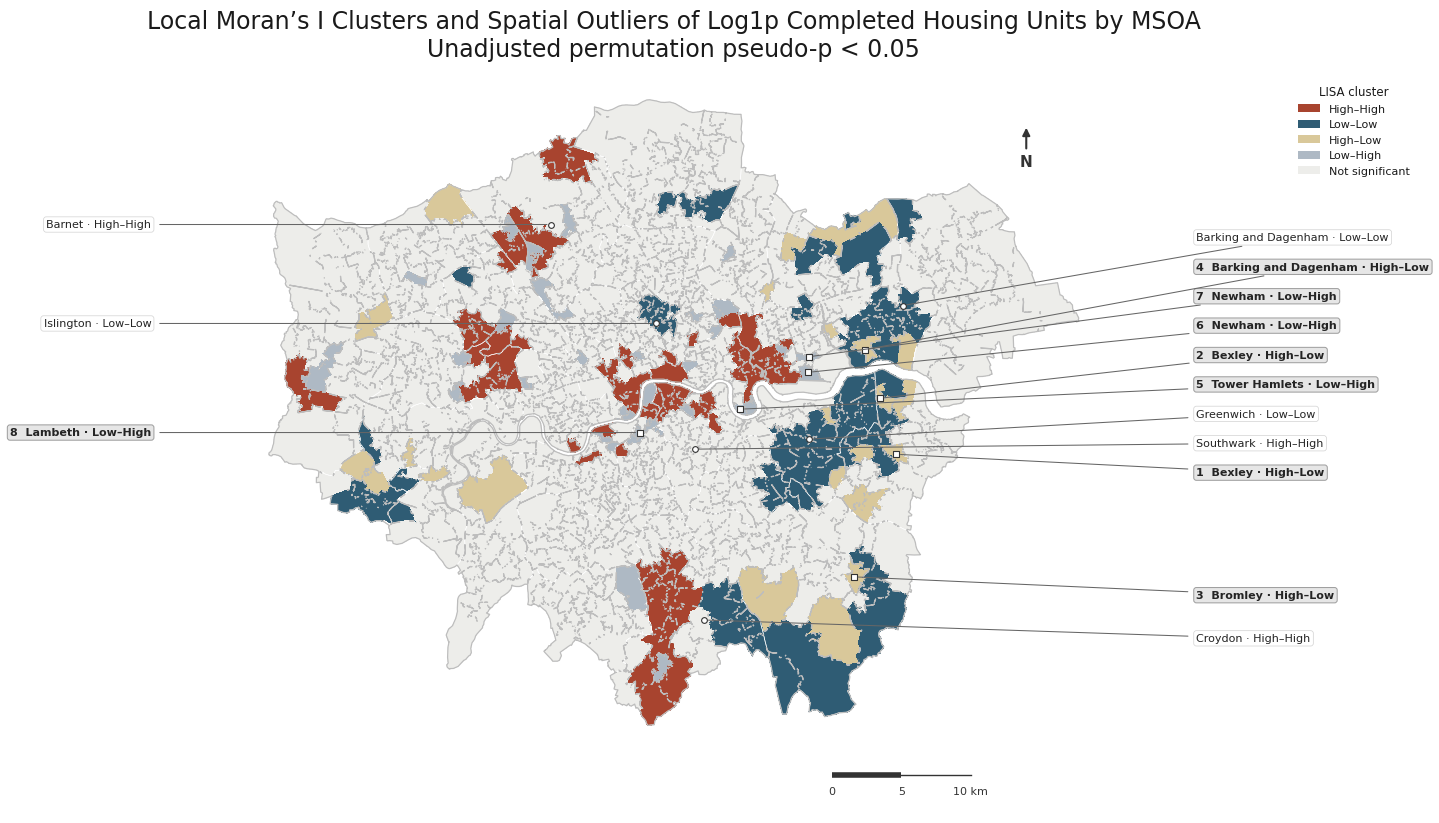

In [31]:
from matplotlib.patches import Patch
import numpy as np
import pandas as pd


# ============================================================
# 1. LISA colour settings
# ============================================================

lisa_colours = {
    "High–High": "#A8442F",
    "Low–Low": "#2F5C74",
    "High–Low": "#D9C89A",
    "Low–High": "#AEB9C4",
    "Not significant": "#EDEDEA",
}

cluster_order = [
    "High–High",
    "Low–Low",
    "High–Low",
    "Low–High",
    "Not significant",
]

spatial_gdf["lisa_colour"] = (
    spatial_gdf["lisa_cluster"]
    .astype(str)
    .map(lisa_colours)
)


# ============================================================
# 2. Select borough-level cluster concentrations
#
# The labels are selected automatically:
# - three boroughs with the largest number of High–High MSOAs;
# - three boroughs with the largest number of Low–Low MSOAs.
# ============================================================

top_hh_boroughs = (
    lisa_borough_summary
    .nlargest(
        3,
        "High–High",
    )["borough"]
    .tolist()
)

top_ll_boroughs = (
    lisa_borough_summary
    .nlargest(
        3,
        "Low–Low",
    )["borough"]
    .tolist()
)

# Combine the two lists and remove duplicates
# while preserving the original order.
label_borough_names = list(
    dict.fromkeys(
        top_hh_boroughs
        + top_ll_boroughs
    )
)

borough_label_points = (
    boroughs.loc[
        boroughs["borough"].isin(
            label_borough_names
        )
    ]
    .copy()
)

borough_label_points["geometry"] = (
    borough_label_points
    .geometry
    .representative_point()
)

print(
    "High–High concentration boroughs:",
    top_hh_boroughs,
)

print(
    "Low–Low concentration boroughs:",
    top_ll_boroughs,
)


# ============================================================
# 3. Helper function to spread labels vertically
# ============================================================

def spread_label_positions(
    records,
    y_min,
    y_max,
    minimum_gap,
):
    """
    Preserve the north-south order of labels while imposing
    a minimum vertical distance between them.
    """

    if not records:
        return records

    records = sorted(
        records,
        key=lambda item: item["target_y"],
    )

    label_y = np.array(
        [
            np.clip(
                item["target_y"],
                y_min,
                y_max,
            )
            for item in records
        ],
        dtype=float,
    )

    # Move overlapping labels upwards.
    for index in range(
        1,
        len(label_y),
    ):
        label_y[index] = max(
            label_y[index],
            label_y[index - 1]
            + minimum_gap,
        )

    # If the top label exceeds the available range,
    # move the whole group down.
    if label_y[-1] > y_max:
        label_y -= (
            label_y[-1]
            - y_max
        )

    # Work backwards to restore minimum spacing.
    for index in range(
        len(label_y) - 2,
        -1,
        -1,
    ):
        label_y[index] = min(
            label_y[index],
            label_y[index + 1]
            - minimum_gap,
        )

    # If the bottom label falls outside the available range,
    # move the whole group upwards.
    if label_y[0] < y_min:
        label_y += (
            y_min
            - label_y[0]
        )

    for item, y_value in zip(
        records,
        label_y,
    ):
        item["label_y"] = y_value

    return records


# ============================================================
# 4. Create external label records
# ============================================================

min_x, min_y, max_x, max_y = (
    spatial_gdf.total_bounds
)

map_width = max_x - min_x
map_height = max_y - min_y

map_centre_x = (
    min_x + max_x
) / 2

label_records = []


# ------------------------------------------------------------
# 4.1 Borough concentration labels
# ------------------------------------------------------------

for _, row in (
    borough_label_points.iterrows()
):

    borough_name = row["borough"]

    concentration_types = []

    if borough_name in top_hh_boroughs:
        concentration_types.append(
            "High–High"
        )

    if borough_name in top_ll_boroughs:
        concentration_types.append(
            "Low–Low"
        )

    concentration_text = " / ".join(
        concentration_types
    )

    label_records.append(
        {
            "label_type": "borough",
            "label_text": (
                f"{borough_name} · "
                f"{concentration_text}"
            ),
            "target_x": row.geometry.x,
            "target_y": row.geometry.y,
            "side": (
                "left"
                if row.geometry.x
                < map_centre_x
                else "right"
            ),
        }
    )


# ------------------------------------------------------------
# 4.2 Numbered High–Low and Low–High outlier labels
# ------------------------------------------------------------

for _, row in (
    selected_outliers.iterrows()
):

    point = (
        row.geometry
        .representative_point()
    )

    borough_name = (
        row["borough"]
        if (
            "borough" in row.index
            and pd.notna(
                row["borough"]
            )
        )
        else row["msoa11cd"]
    )

    label_records.append(
        {
            "label_type": "outlier",
            "label_text": (
                f"{int(row['map_label'])}  "
                f"{borough_name} · "
                f"{row['lisa_cluster']}"
            ),
            "target_x": point.x,
            "target_y": point.y,
            "side": (
                "left"
                if point.x
                < map_centre_x
                else "right"
            ),
        }
    )


left_label_records = [
    item
    for item in label_records
    if item["side"] == "left"
]

right_label_records = [
    item
    for item in label_records
    if item["side"] == "right"
]


# ============================================================
# 5. Arrange external label positions
# ============================================================

label_y_min = (
    min_y
    + map_height * 0.07
)

label_y_max = (
    max_y
    - map_height * 0.07
)

minimum_label_gap = (
    map_height * 0.047
)


# Left-side labels can use most of the map height.
left_label_records = (
    spread_label_positions(
        left_label_records,
        y_min=label_y_min,
        y_max=label_y_max,
        minimum_gap=minimum_label_gap,
    )
)


# Reserve the upper-right area for the legend.
right_label_records = (
    spread_label_positions(
        right_label_records,
        y_min=label_y_min,
        y_max=(
            max_y
            - map_height * 0.22
        ),
        minimum_gap=minimum_label_gap,
    )
)


# ============================================================
# 6. Draw the map
# ============================================================

fig, ax = plt.subplots(
    figsize=(14.5, 9.5),
    facecolor="#FFFFFF",
)


spatial_gdf.plot(
    color=spatial_gdf[
        "lisa_colour"
    ],
    linewidth=0,
    edgecolor="none",
    antialiased=False,
    ax=ax,
    zorder=5,
)

remove_polygon_seams(ax)


# Borough boundaries
boroughs.boundary.plot(
    ax=ax,
    color="#FFFFFF",
    linewidth=0.45,
    alpha=0.95,
    zorder=10,
)


# London-wide outer boundary
spatial_gdf.dissolve().boundary.plot(
    ax=ax,
    color="#BDBDBD",
    linewidth=0.9,
    zorder=12,
)


# ============================================================
# 7. Expand the map extent
#
# Horizontal space is added for external labels.
# Extra space is added below the map for the scale bar.
# ============================================================

left_label_x = (
    min_x
    - map_width * 0.145
)

right_label_x = (
    max_x
    + map_width * 0.145
)

ax.set_xlim(
    min_x - map_width * 0.25,
    max_x + map_width * 0.25,
)

# The larger lower margin keeps the scale bar
# entirely below the London boundary.
ax.set_ylim(
    min_y - map_height * 0.14,
    max_y + map_height * 0.03,
)


# ============================================================
# 8. Draw external labels and straight leader lines
# ============================================================

def draw_external_labels(
    ax,
    records,
    label_x,
    side,
):
    """
    Draw borough and outlier labels outside the map.

    Borough concentration labels:
    - normal-weight text;
    - white background.

    Numbered outlier labels:
    - bold text;
    - light-grey background;
    - stronger outline.
    """

    horizontal_alignment = (
        "right"
        if side == "left"
        else "left"
    )

    for item in records:

        if item["label_type"] == "outlier":

            # Emphasised numbered outlier labels
            marker = "s"
            marker_size = 20

            box_face_colour = "#E6E6E6"
            box_edge_colour = "#9E9E9E"
            box_linewidth = 0.75

            font_weight = "bold"

        else:

            # Secondary borough concentration labels
            marker = "o"
            marker_size = 17

            box_face_colour = "#FFFFFF"
            box_edge_colour = "#D0D0D0"
            box_linewidth = 0.5

            font_weight = "normal"

        # Marker at the relevant location on the map
        ax.scatter(
            item["target_x"],
            item["target_y"],
            s=marker_size,
            marker=marker,
            facecolor="#FFFFFF",
            edgecolor="#333333",
            linewidth=0.8,
            zorder=26,
        )

        # External annotation and straight leader line
        ax.annotate(
            item["label_text"],
            xy=(
                item["target_x"],
                item["target_y"],
            ),
            xytext=(
                label_x,
                item["label_y"],
            ),
            textcoords="data",
            ha=horizontal_alignment,
            va="center",
            fontsize=8,
            fontweight=font_weight,
            color="#242424",
            arrowprops={
                "arrowstyle": "-",
                "connectionstyle": "arc3,rad=0",
                "color": "#666666",
                "linewidth": 0.75,
                "shrinkA": 4,
                "shrinkB": 3,
            },
            bbox={
                "boxstyle": "round,pad=0.24",
                "facecolor": box_face_colour,
                "edgecolor": box_edge_colour,
                "linewidth": box_linewidth,
                "alpha": 0.97,
            },
            annotation_clip=False,
            zorder=30,
        )


draw_external_labels(
    ax=ax,
    records=left_label_records,
    label_x=left_label_x,
    side="left",
)

draw_external_labels(
    ax=ax,
    records=right_label_records,
    label_x=right_label_x,
    side="right",
)


# ============================================================
# 9. Legend — retain upper-right position
# ============================================================

legend_handles = [
    Patch(
        facecolor=lisa_colours[label],
        edgecolor="none",
        label=label,
    )
    for label in cluster_order
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    frameon=False,
    title="LISA cluster",
    fontsize=8,
    title_fontsize=8.5,
    borderaxespad=0,
)


# ============================================================
# 10. Title and map elements
# ============================================================

ax.set_title(
    "Local Moran’s I Clusters and Spatial Outliers "
    "of Log1p Completed Housing Units by MSOA\n"
    "Unadjusted permutation pseudo-p < 0.05",
    pad=18,
)

ax.axis("off")


# Scale bar is positioned in the blank margin
# beneath the London boundary.
add_scale_bar(
    ax,
    length_km=10,
    location=(
        0.63,
        0.052,
    ),
)


# North arrow remains inside the upper map area.
add_north_arrow(
    ax,
    location=(
        0.79,
        0.89,
    ),
)


plt.subplots_adjust(
    left=0.03,
    right=0.88,
    top=0.90,
    bottom=0.03,
)


save_figure(
    "fig05g_msoa_housing_lisa_clusters_annotated.png"
)

## 7. Simple regressions

### 7.1 Prepare the regression dataset

In [32]:
model_data = (
    msoa_analysis[
        [
            "msoa11cd",
            "log_housing_units",
            "housing_units",
            "housing_units_per_km2",
            "mean_ptal",
            "medium_high_ptal_share",
            "mean_imd_score",
            "area_km2",
            "log_area_km2",
            "geometry",
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "log_housing_units",
            "mean_ptal",
            "mean_imd_score",
            "log_area_km2",
            "geometry",
        ]
    )
    .reset_index(drop=True)
    .copy()
)

print("Regression observations:", len(model_data))

model_data[
    [
        "log_housing_units",
        "mean_ptal",
        "mean_imd_score",
        "area_km2",
    ]
].describe().T

Regression observations: 983


,count,mean,std,min,25%,50%,75%,max
log_housing_units,983.0,4.653118,1.244983,0.000000,3.871201,4.653960,5.455321,8.523772
mean_ptal,983.0,3.633966,1.597943,0.376245,2.504628,3.299065,4.655811,8.000000
mean_imd_score,983.0,21.563737,9.453347,4.062400,13.746804,21.198167,28.748100,50.422500
area_km2,983.0,1.600718,1.861482,0.293826,0.715431,1.145956,1.754146,22.448181


### 7.2 Estimate four OLS models

In [33]:
model_1 = smf.ols(
    "log_housing_units ~ medium_high_ptal_share",
    data=model_data,
).fit(
    cov_type="HC3"
)

model_2 = smf.ols(
    "log_housing_units ~ mean_imd_score",
    data=model_data,
).fit(
    cov_type="HC3"
)

model_3 = smf.ols(
    "log_housing_units ~ "
    "medium_high_ptal_share + "
    "mean_imd_score",
    data=model_data,
).fit(
    cov_type="HC3"
)

model_4 = smf.ols(
    "log_housing_units ~ "
    "medium_high_ptal_share + "
    "mean_imd_score + "
    "log_area_km2",
    data=model_data,
).fit(
    cov_type="HC3"
)

regression_table = summary_col(
    [
        model_1,
        model_2,
        model_3,
        model_4,
    ],
    stars=True,
    model_names=[
        "M1",
        "M2",
        "M3",
        "M4",
    ],

    # summary_col already includes R-squared and adjusted R-squared.
    # Only add the sample size here.
    info_dict={
        "N": lambda model: f"{int(model.nobs)}",
    },
)

print(regression_table)


                           M1        M2        M3        M4   
--------------------------------------------------------------
Intercept              4.1714*** 4.3363*** 4.1083*** 3.4206***
                       (0.0642)  (0.0940)  (0.0919)  (0.1214) 
medium_high_ptal_share 1.0443***           1.0162*** 1.8676***
                       (0.1081)            (0.1173)  (0.1486) 
mean_imd_score                   0.0147*** 0.0035    0.0114***
                                 (0.0042)  (0.0044)  (0.0044) 
log_area_km2                                         0.6942***
                                                     (0.0812) 
R-squared              0.0869    0.0124    0.0876    0.1631   
R-squared Adj.         0.0860    0.0114    0.0857    0.1605   
N                      983       983       983       983      
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


### 7.2.1 Multicollinearity diagnostic

In [34]:
# ---------------------------------------------------------
# Variance inflation factors for Model 4
# ---------------------------------------------------------

# Use exactly the three explanatory variables included
# in Model 4.
vif_variables = [
    "medium_high_ptal_share",
    "mean_imd_score",
    "log_area_km2",
]

# Keep complete numeric observations.
vif_data = (
    model_data[vif_variables]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
    .copy()
)

# Add the regression intercept.
vif_design = sm.add_constant(
    vif_data,
    has_constant="add",
)

# Calculate VIF for every column.
vif_results = []

for column_index, variable_name in enumerate(
    vif_design.columns
):

    vif_results.append({
        "variable": variable_name,
        "VIF": variance_inflation_factor(
            vif_design.values,
            column_index,
        ),
    })

vif_table = pd.DataFrame(
    vif_results
)

# The intercept is not substantively interpreted.
vif_table = (
    vif_table[
        vif_table["variable"] != "const"
    ]
    .reset_index(drop=True)
)

# Save the result.
vif_table.to_csv(
    OUTPUT_DIR
    / "05_model_4_vif.csv",
    index=False,
)

display(
    vif_table.round(3)
)

,variable,VIF
0,medium_high_ptal_share,1.860
1,mean_imd_score,1.143
2,log_area_km2,1.924


### 7.3 Export regression results

In [35]:
regression_table_text = regression_table.as_text()

with open(
    OUTPUT_DIR / "05_regression_results.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(regression_table_text)

for number, model in enumerate(
    [model_1, model_2, model_3, model_4],
    start=1,
):
    model.params.rename("coefficient").to_csv(
        OUTPUT_DIR / f"05_model_{number}_coefficients.csv"
    )

### 7.4 Moran’s I of Model 4 residuals

In [36]:
model_spatial = gpd.GeoDataFrame(
    model_data.copy(),
    geometry="geometry",
    crs=msoa_analysis.crs,
)

model_spatial["model_4_residual"] = model_4.resid.values
model_spatial = model_spatial.reset_index(drop=True)

# Use the same 8-nearest-neighbour weights as the main spatial analysis
w_model = KNN.from_dataframe(
    model_spatial,
    k=8,
    use_index=True,
)

w_model = w_model.symmetrize()
w_model.transform = "r"

print("Number of observations:", w_model.n)
print("Minimum neighbours:", min(w_model.cardinalities.values()))
print("Maximum neighbours:", max(w_model.cardinalities.values()))
print("Disconnected observations:", len(w_model.islands))
print("Island indices:", w_model.islands)

residual_moran = Moran(
    model_spatial["model_4_residual"].astype(float).values,
    w_model,
    permutations=999,
)

residual_moran_result = pd.DataFrame(
    {
        "measure": [
            "Moran's I",
            "Expected I",
            "Pseudo p-value",
            "Z-score",
        ],
        "value": [
            residual_moran.I,
            residual_moran.EI,
            residual_moran.p_sim,
            residual_moran.z_sim,
        ],
    }
)

residual_moran_result.to_csv(
    OUTPUT_DIR / "05_msoa_model_4_residual_morans_i.csv",
    index=False,
)

residual_moran_result.round(4)

Number of observations: 983
Minimum neighbours: 8
Maximum neighbours: 14
Disconnected observations: 0
Island indices: []


,measure,value
0,Moran's I,0.1645
1,Expected I,-0.0010
2,Pseudo p-value,0.0010
3,Z-score,11.4014


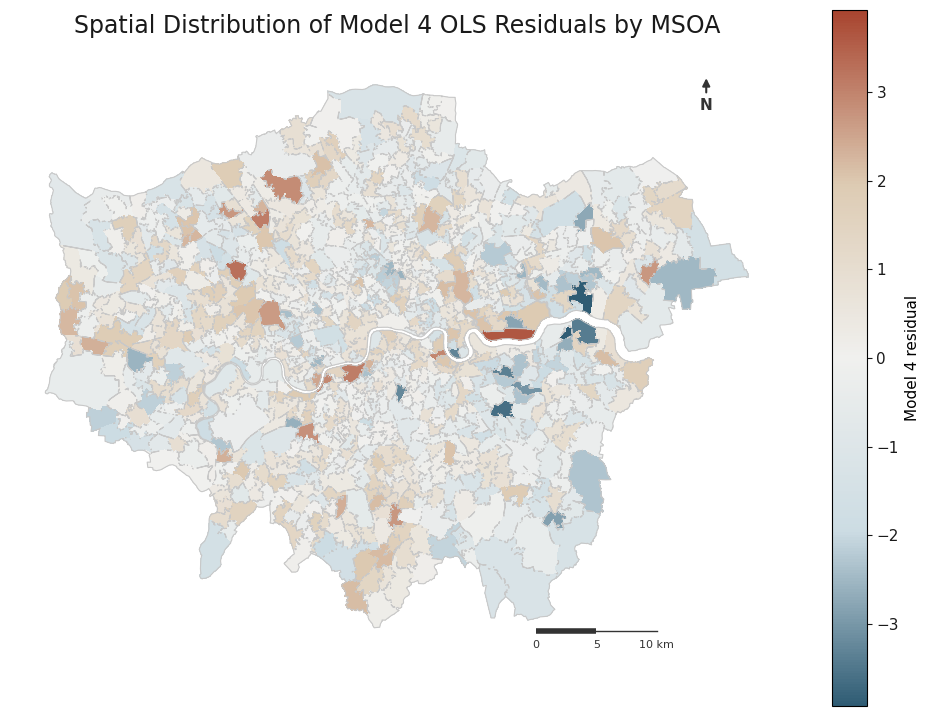

In [37]:
from matplotlib.colors import (
    LinearSegmentedColormap,
    TwoSlopeNorm,
)


diverging_cmap = LinearSegmentedColormap.from_list(
    "residual_fresh",
    [
        "#2F5C74",
        "#CCDCE3",
        "#F0F0EE",
        "#DDCBB3",
        "#A8442F",
    ],
)

residual_limit = np.nanmax(
    np.abs(
        model_spatial["model_4_residual"]
    )
)

residual_norm = TwoSlopeNorm(
    vmin=-residual_limit,
    vcenter=0,
    vmax=residual_limit,
)

fig, ax = plt.subplots(
    figsize=(10, 10),
    facecolor="#FFFFFF",
)

model_spatial.plot(
    column="model_4_residual",
    cmap=diverging_cmap,
    norm=residual_norm,
    legend=True,

    linewidth=0,
    edgecolor="none",
    antialiased=False,

    ax=ax,
    legend_kwds={
        "label": "Model 4 residual",
        "shrink": 0.72,
    },
    zorder=5,
)

remove_polygon_seams(ax)

london_outline.boundary.plot(
    ax=ax,
    color="#C8C8C8",
    linewidth=0.8,
    zorder=10,
)

ax.set_title(
    "Spatial Distribution of Model 4 OLS Residuals by MSOA",
    pad=18,
    color="#1A1A1A",
)

ax.axis("off")

add_scale_bar(
    ax,
    length_km=10,
    location=(0.68, 0.04),
)

add_north_arrow(
    ax,
    location=(0.90, 0.92),
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig05i_msoa_model_4_residuals.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="#FFFFFF",
    pad_inches=0.18,
)

plt.show()

### 7.5 Spatial-weight sensitivity

In [38]:
# ---------------------------------------------------------
# Spatial-weight sensitivity:
# compare KNN specifications with k = 4, 8 and 12
# ---------------------------------------------------------

# Set a random seed so that the permutation tests
# can be reproduced.
np.random.seed(20260720)

weight_sensitivity_results = []

# Variables included in the original Global Moran's I
# analysis.
global_moran_variables = {
    "Log1p completed housing units":
        "log_housing_units",

    "Mean PTAL":
        "mean_ptal",

    "Mean IMD score":
        "mean_imd_score",
}

for k_value in [
    4,
    8,
    12,
]:

    # -----------------------------------------------------
    # A. Global Moran's I for the three MSOA variables
    # -----------------------------------------------------

    w_global = KNN.from_dataframe(
        spatial_gdf,
        k=k_value,
        use_index=True,
    )

    # Match the treatment used in the main analysis:
    # symmetric and row-standardised weights.
    w_global = w_global.symmetrize()
    w_global.transform = "r"

    for (
        variable_label,
        variable_column,
    ) in global_moran_variables.items():

        moran_result = Moran(
            spatial_gdf[
                variable_column
            ]
            .astype(float)
            .values,
            w_global,
            permutations=999,
        )

        weight_sensitivity_results.append({
            "analysis": variable_label,
            "k": k_value,
            "morans_i": moran_result.I,
            "expected_i": moran_result.EI,
            "pseudo_p_value": moran_result.p_sim,
            "z_score": moran_result.z_sim,
            "minimum_neighbours": min(
                w_global.cardinalities.values()
            ),
            "maximum_neighbours": max(
                w_global.cardinalities.values()
            ),
            "number_of_islands": len(
                w_global.islands
            ),
        })

    # -----------------------------------------------------
    # B. Moran's I for Model 4 residuals
    # -----------------------------------------------------

    w_residual = KNN.from_dataframe(
        model_spatial,
        k=k_value,
        use_index=True,
    )

    w_residual = w_residual.symmetrize()
    w_residual.transform = "r"

    residual_moran_result = Moran(
        model_spatial[
            "model_4_residual"
        ]
        .astype(float)
        .values,
        w_residual,
        permutations=999,
    )

    weight_sensitivity_results.append({
        "analysis": "Model 4 residuals",
        "k": k_value,
        "morans_i":
            residual_moran_result.I,
        "expected_i":
            residual_moran_result.EI,
        "pseudo_p_value":
            residual_moran_result.p_sim,
        "z_score":
            residual_moran_result.z_sim,
        "minimum_neighbours": min(
            w_residual.cardinalities.values()
        ),
        "maximum_neighbours": max(
            w_residual.cardinalities.values()
        ),
        "number_of_islands": len(
            w_residual.islands
        ),
    })

# Convert all results into one table.
weight_sensitivity_table = pd.DataFrame(
    weight_sensitivity_results
)

# Order the table for easier comparison.
analysis_order = [
    "Log1p completed housing units",
    "Mean PTAL",
    "Mean IMD score",
    "Model 4 residuals",
]

weight_sensitivity_table[
    "analysis"
] = pd.Categorical(
    weight_sensitivity_table[
        "analysis"
    ],
    categories=analysis_order,
    ordered=True,
)

weight_sensitivity_table = (
    weight_sensitivity_table
    .sort_values(
        [
            "analysis",
            "k",
        ]
    )
    .reset_index(drop=True)
)

# Save the complete result.
weight_sensitivity_table.to_csv(
    OUTPUT_DIR
    / "05_spatial_weight_sensitivity.csv",
    index=False,
)

display(
    weight_sensitivity_table[
        [
            "analysis",
            "k",
            "morans_i",
            "pseudo_p_value",
            "z_score",
            "minimum_neighbours",
            "maximum_neighbours",
            "number_of_islands",
        ]
    ].round(4)
)

,analysis,k,morans_i,pseudo_p_value,z_score,minimum_neighbours,maximum_neighbours,number_of_islands
0,Log1p completed housing units,4,0.1866,0.001,9.0351,4,7,0
1,Log1p completed housing units,8,0.1784,0.001,11.8780,8,14,0
2,Log1p completed housing units,12,0.1616,0.001,13.7045,12,21,0
3,Mean PTAL,4,0.7278,0.001,34.4303,4,7,0
4,Mean PTAL,8,0.6851,0.001,45.1685,8,14,0
5,Mean PTAL,12,0.6507,0.001,53.6562,12,21,0
6,Mean IMD score,4,0.6134,0.001,29.8147,4,7,0
7,Mean IMD score,8,0.5417,0.001,35.5859,8,14,0
8,Mean IMD score,12,0.4936,0.001,40.7732,12,21,0
9,Model 4 residuals,4,0.1765,0.001,8.3536,4,7,0


In [39]:
# ---------------------------------------------------------
# Simplified table for reporting in the dissertation
# ---------------------------------------------------------

weight_sensitivity_summary = (
    weight_sensitivity_table[
        [
            "analysis",
            "k",
            "morans_i",
            "pseudo_p_value",
        ]
    ]
    .copy()
)

weight_sensitivity_summary.to_csv(
    OUTPUT_DIR
    / "05_spatial_weight_sensitivity_summary.csv",
    index=False,
)

display(
    weight_sensitivity_summary.round(4)
)

,analysis,k,morans_i,pseudo_p_value
0,Log1p completed housing units,4,0.1866,0.001
1,Log1p completed housing units,8,0.1784,0.001
2,Log1p completed housing units,12,0.1616,0.001
3,Mean PTAL,4,0.7278,0.001
4,Mean PTAL,8,0.6851,0.001
5,Mean PTAL,12,0.6507,0.001
6,Mean IMD score,4,0.6134,0.001
7,Mean IMD score,8,0.5417,0.001
8,Mean IMD score,12,0.4936,0.001
9,Model 4 residuals,4,0.1765,0.001


## 8. Export final spatial datasets

In [40]:
msoa_analysis.to_file(
    OUTPUT_DIR / "05_msoa_spatial_analysis.gpkg",
    driver="GPKG",
)

msoa_analysis.drop(columns="geometry").to_csv(
    OUTPUT_DIR / "05_msoa_spatial_analysis.csv",
    index=False,
)

spatial_gdf.to_file(
    OUTPUT_DIR / "05_msoa_lisa_results.gpkg",
    driver="GPKG",
)

print("Export complete.")
print("Main dataset:", OUTPUT_DIR / "05_msoa_spatial_analysis.gpkg")
print("LISA dataset:", OUTPUT_DIR / "05_msoa_lisa_results.gpkg")
print("Figures:", FIG_DIR)

Export complete.
Main dataset: outputs\05_msoa_spatial_analysis.gpkg
LISA dataset: outputs\05_msoa_lisa_results.gpkg
Figures: outputs\figures


## 9. Output inventory

Use the following outputs in the main text:

- MSOA housing delivery map  
- MSOA mean PTAL map  
- MSOA deprivation map  
- Pearson and Spearman correlation table  
- Global Moran’s I table  
- Housing LISA cluster map  
- Regression table for Models 1–4  
- Moran’s I test of Model 4 residuals